<a href="https://colab.research.google.com/github/HayaFatima-003/Data-Science/blob/main/Assignment%202%20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **DATA EXPLORATION**

1. Load the dataset and review its structure.

In [6]:
df= pd.read_csv('Employee.csv')
df

,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1
...,...,...,...,...,...,...,...,...,...
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   Education                  4653 non-null   object
 1   JoiningYear                4653 non-null   int64 
 2   City                       4653 non-null   object
 3   PaymentTier                4653 non-null   int64 
 4   Age                        4653 non-null   int64 
 5   Gender                     4653 non-null   object
 6   EverBenched                4653 non-null   object
 7   ExperienceInCurrentDomain  4653 non-null   int64 
 8   LeaveOrNot                 4653 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 327.3+ KB


2. Identify the categorical and numerical features.

In [18]:
categorical_features = df.select_dtypes(include=['object']).columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
print("Categorical Features",categorical_features)
print("Numerical Features",numerical_features)

Categorical Features Index(['Education', 'City', 'Gender', 'EverBenched'], dtype='object')
Numerical Features Index(['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain',
       'LeaveOrNot'],
      dtype='object')


3. Check for missing values.

In [11]:
df.isnull().sum()

,0
Education,0
JoiningYear,0
City,0
PaymentTier,0
Age,0
Gender,0
EverBenched,0
ExperienceInCurrentDomain,0
LeaveOrNot,0


4. Compute summary statistics for numerical features (Age, PaymentTier, ExperienceInCurrentDomain).

In [12]:
df[['Age', 'PaymentTier', 'ExperienceInCurrentDomain']].describe()

,Age,PaymentTier,ExperienceInCurrentDomain
count,4653.000000,4653.000000,4653.000000
mean,29.393295,2.698259,2.905652
std,4.826087,0.561435,1.558240
min,22.000000,1.000000,0.000000
25%,26.000000,3.000000,2.000000
50%,28.000000,3.000000,3.000000
75%,32.000000,3.000000,4.000000
max,41.000000,3.000000,7.000000


5. Analyze the distribution of categorical features (Education, City, Gender, EverBenched).

In [20]:
df[['Education', 'City', 'Gender', 'EverBenched']].describe()

,Education,City,Gender,EverBenched
count,4653,4653,4653,4653
unique,3,3,2,2
top,Bachelors,Bangalore,Male,No
freq,3601,2228,2778,4175


Plot or visualize the distribution of the target variable LeaveOrNot.

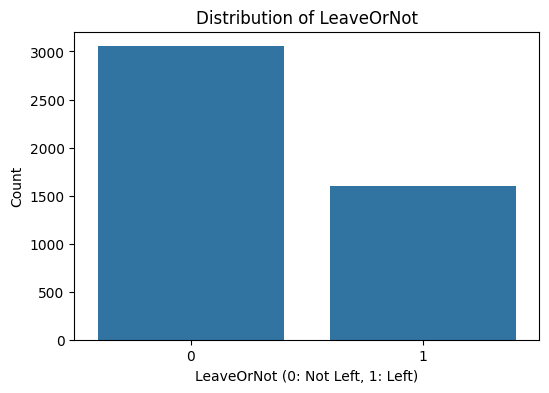

In [21]:
plt.figure(figsize=(6, 4))
sns.countplot(x='LeaveOrNot', data=df)
plt.title('Distribution of LeaveOrNot')
plt.xlabel('LeaveOrNot (0: Not Left, 1: Left)')
plt.ylabel('Count')
plt.show()

# **Data Preprocessing**

1. Encode categorical features (Education, City, Gender, EverBenched) appropriately.

In [22]:
from sklearn.preprocessing import LabelEncoder

# One-hot encode 'Education' and 'City'
df = pd.get_dummies(df, columns=['Education', 'City'], drop_first=True)

# Label encode 'Gender' and 'EverBenched'
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['EverBenched'] = le.fit_transform(df['EverBenched'])

display(df.head())

,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune
0,2017,3,34,1,0,0,0,False,False,False,False
1,2013,1,28,0,0,3,1,False,False,False,True
2,2014,3,38,0,0,2,0,False,False,True,False
3,2016,3,27,1,0,5,1,True,False,False,False
4,2017,3,24,1,1,2,1,True,False,False,True


2. Handle scaling of numerical features if needed (Age, ExperienceInCurrentDomain, JoiningYear, PaymentTier).

In [23]:
from sklearn.preprocessing import StandardScaler

numerical_features_to_scale = ['Age', 'JoiningYear', 'PaymentTier', 'ExperienceInCurrentDomain']

scaler = StandardScaler()
df[numerical_features_to_scale] = scaler.fit_transform(df[numerical_features_to_scale])

display(df.head())

,JoiningYear,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot,Education_Masters,Education_PHD,City_New Delhi,City_Pune
0,1.039638,0.537503,0.954645,1,0,-1.864901,0,False,False,False,False
1,-1.107233,-3.025177,-0.288732,0,0,0.060554,1,False,False,False,True
2,-0.570515,0.537503,1.783563,0,0,-0.581264,0,False,False,True,False
3,0.502921,0.537503,-0.495961,1,0,1.344191,1,True,False,False,False
4,1.039638,0.537503,-1.117650,1,1,-0.581264,1,True,False,False,True


3. Split the dataset into training and testing sets (suggested: 80%-20%).

In [24]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('LeaveOrNot', axis=1)
y = df['LeaveOrNot']

In [25]:
# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3722, 10)
X_test shape: (931, 10)
y_train shape: (3722,)
y_test shape: (931,)


## Model Training

Let's train a Logistic Regression model, which is a common choice for binary classification problems.

In [26]:
from sklearn.linear_model import LogisticRegression

# Initialize the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # Using 'liblinear' solver for better performance on smaller datasets

# Train the model using the training data
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


# **Model Building and Evaluation**

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.7422
Precision: 0.7077
Recall: 0.4299
F1-Score: 0.5349

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.91      0.82       610
           1       0.71      0.43      0.53       321

    accuracy                           0.74       931
   macro avg       0.73      0.67      0.68       931
weighted avg       0.74      0.74      0.72       931


Confusion Matrix:
[[553  57]
 [183 138]]


### Decision Tree Classifier



In [28]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

# Make predictions
dt_y_pred = dt_model.predict(X_test)

# Evaluate the Decision Tree model
dt_accuracy = accuracy_score(y_test, dt_y_pred)
dt_precision = precision_score(y_test, dt_y_pred)
dt_recall = recall_score(y_test, dt_y_pred)
dt_f1 = f1_score(y_test, dt_y_pred)

print(f"\nDecision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree Precision: {dt_precision:.4f}")
print(f"Decision Tree Recall: {dt_recall:.4f}")
print(f"Decision Tree F1-Score: {dt_f1:.4f}")

print("\nDecision Tree Classification Report:")
print(classification_report(y_test, dt_y_pred))

Decision Tree Classifier trained successfully!

Decision Tree Accuracy: 0.8389
Decision Tree Precision: 0.7879
Decision Tree Recall: 0.7290
Decision Tree F1-Score: 0.7573

Decision Tree Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.90      0.88       610
           1       0.79      0.73      0.76       321

    accuracy                           0.84       931
   macro avg       0.83      0.81      0.82       931
weighted avg       0.84      0.84      0.84       931



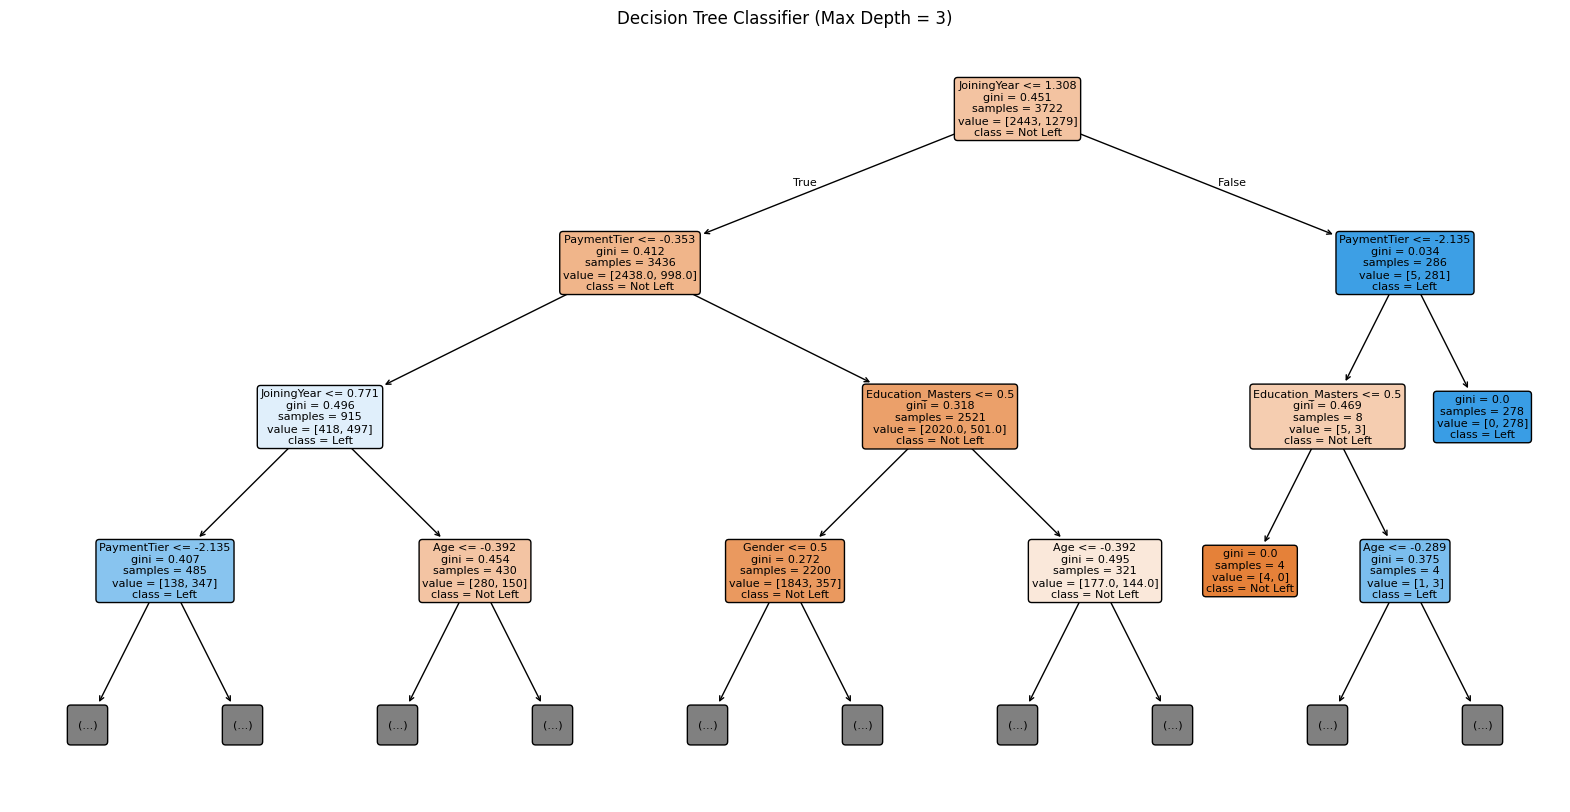

In [30]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10)) # Adjust figure size as needed
plot_tree(dt_model,
          feature_names=X.columns.tolist(), # Use actual column names
          class_names=['Not Left', 'Left'], # Use meaningful class names
          filled=True,
          rounded=True,
          fontsize=8,
          max_depth=3) # Limit depth for better visualization if the tree is large
plt.title('Decision Tree Classifier (Max Depth = 3)')
plt.show()

### Random Forest Classifier



In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest Classifier trained successfully!")

# Make predictions
rf_y_pred = rf_model.predict(X_test)

# Evaluate the Random Forest model
rf_accuracy = accuracy_score(y_test, rf_y_pred)
rf_precision = precision_score(y_test, rf_y_pred)
rf_recall = recall_score(y_test, rf_y_pred)
rf_f1 = f1_score(y_test, rf_y_pred)

print(f"\nRandom Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest Precision: {rf_precision:.4f}")
print(f"Random Forest Recall: {rf_recall:.4f}")
print(f"Random Forest F1-Score: {rf_f1:.4f}")

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_y_pred))

Random Forest Classifier trained successfully!

Random Forest Accuracy: 0.8496
Random Forest Precision: 0.8153
Random Forest Recall: 0.7290
Random Forest F1-Score: 0.7697

Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.91      0.89       610
           1       0.82      0.73      0.77       321

    accuracy                           0.85       931
   macro avg       0.84      0.82      0.83       931
weighted avg       0.85      0.85      0.85       931



/tmp/ipykernel_5149/4217542240.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')


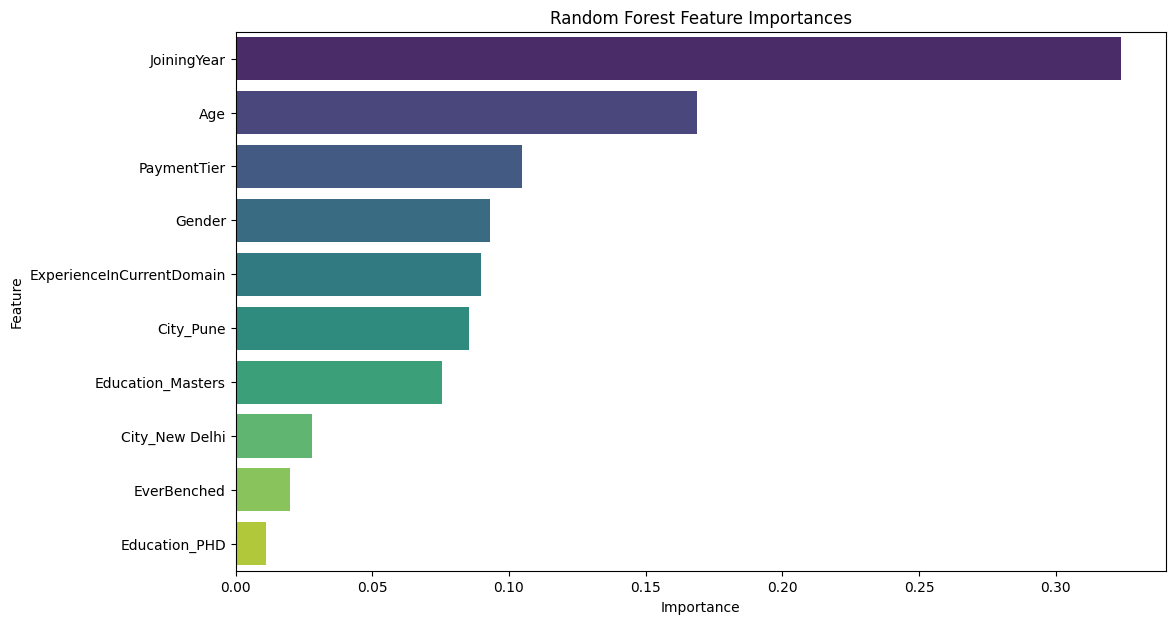

In [31]:
importances = rf_model.feature_importances_
feature_names = X.columns

# Create a DataFrame for better visualization
feature_importances_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
feature_importances_df = feature_importances_df.sort_values(by='importance', ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x='importance', y='feature', data=feature_importances_df, palette='viridis')
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

# **Analysis Questions**

### 1. Which features are most important in predicting employee attrition?

Based on the Random Forest Feature Importances, the most important features in predicting employee attrition are:

1.  **JoiningYear** (Importance: 0.324)
2.  **Age** (Importance: 0.169)
3.  **PaymentTier** (Importance: 0.105)
4.  **Gender** (Importance: 0.093)
5.  **ExperienceInCurrentDomain** (Importance: 0.090)

These features contribute most significantly to the model's ability to predict whether an employee will leave or not.

### 2. How do Age and ExperienceInCurrentDomain affect the likelihood of leaving?

*   **Age**: Age is a significant predictor, being the second most important feature. Generally, it can indicate career stage or life events that influence attrition. For a deeper understanding of the specific relationship (e.g., if younger or older employees are more likely to leave), further analysis like partial dependence plots or examining feature interactions would be beneficial. However, its high importance suggests it's a critical factor.

*   **ExperienceInCurrentDomain**: This feature also has a notable importance (5th highest). It is likely that employees with very low or very high experience in their current domain might have different reasons for leaving or staying. For instance, new employees might leave if the role isn't a good fit, while highly experienced employees might seek new challenges or better opportunities elsewhere. More detailed analysis would be needed to determine the exact nature of this relationship.

### 3. Compare Decision Tree and Random Forest results. Which model performs better and why?

Comparing the evaluation metrics:

| Metric    | Logistic Regression | Decision Tree | Random Forest |
| :-------- | :------------------ | :------------ | :------------ |
| Accuracy  | 0.7422              | 0.8389        | **0.8496**    |
| Precision | 0.7077              | 0.7879        | **0.8153**    |
| Recall    | 0.4299              | 0.7290        | 0.7290        |
| F1-Score  | 0.5349              | 0.7573        | **0.7697**    |

The **Random Forest Classifier** generally performs better than both Logistic Regression and Decision Tree on this dataset. It shows the highest Accuracy, Precision, and F1-Score. While its Recall is the same as the Decision Tree (for the positive class), its overall performance across multiple metrics is superior.

**Why Random Forest performs better:**

Random Forest is an ensemble learning method that builds multiple decision trees and merges their predictions. This approach typically leads to:
*   **Reduced Overfitting**: By averaging multiple trees, Random Forest mitigates the overfitting issues often seen in individual decision trees.
*   **Improved Generalization**: It tends to generalize better to unseen data due to the diversity of the trees and the bagging technique.
*   **Higher Robustness**: It is less sensitive to noisy data compared to single decision trees.

### 4. Suggest HR strategies based on your analysis.

Based on the analysis, particularly the feature importances, here are some HR strategies:

1.  **Focus on Onboarding and Early Career Engagement (JoiningYear):** Since 'JoiningYear' is the most important feature, HR should closely monitor employees in their initial years. Implementing robust onboarding programs, mentorship initiatives, and regular check-ins during the first 1-3 years could help reduce early attrition.

2.  **Tailored Retention Programs by Age Group (Age):** Given the importance of 'Age,' HR could develop retention strategies that cater to different age groups' needs. For instance, career development opportunities for younger employees and work-life balance or specialized benefits for more experienced staff.

3.  **Review Payment Tier Structures and Fairness (PaymentTier):** 'PaymentTier' being a significant factor suggests that compensation and perceived fairness in pay structure play a role in attrition. HR should regularly review salary bands, ensure competitive compensation, and address any perceived inequities.

4.  **Promote Inclusivity and Address Gender-Specific Concerns (Gender):** The importance of 'Gender' indicates potential differences in attrition rates between genders. HR should investigate underlying reasons, which could include promoting an inclusive culture, addressing unconscious biases, ensuring equal growth opportunities, and supporting work-life balance for all employees.

5.  **Career Pathing and Skill Development (ExperienceInCurrentDomain):** For employees with specific 'ExperienceInCurrentDomain' levels, HR can offer clear career progression paths, opportunities for skill development, and cross-functional exposure to keep them engaged and prevent stagnation or feeling undervalued.